# 02. Compensation & Employment Dynamics

This notebook analyzes global compensation and employment dynamics among developers from 2021 to 2025. We cover:
1. Global median salary trends by country
2. Salary vs. professional experience
3. Salary by education level
4. Employment status distribution
5. Salary vs. organization size

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Resolve path to sql_connector relative to this notebook
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
silver_utils_dir = os.path.join(project_root, 'Data Warehouse', 'Silver Layer', 'utils')
sys.path.append(silver_utils_dir)

# Ensure the images output directory exists
images_dir = os.path.join(current_dir, 'images')
os.makedirs(images_dir, exist_ok=True)

from sql_connector import SQLConnector

db = SQLConnector("Stack_Overflow_Survey")
db.connect()

Successfully Connected to Stack_Overflow_Survey


### 1. Global Salary Trends by Top Countries

We focus on the top countries by respondent volume and plot their median salary trajectory from 2021 to 2025.

In [25]:
imputed_values = [56211.0, 67845.0, 74963.0, 65000.0, 75320.0]
region_map = {
        'United States of America': 'North America', 'Canada': 'North America',
        
        # Europe
        'Germany': 'Europe', 'United Kingdom of Great Britain and Northern Ireland': 'Europe',
        'Belgium': 'Europe', 'Netherlands': 'Europe', 'Sweden': 'Europe', 'Italy': 'Europe',
        'Romania': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe', 'France': 'Europe',
        'Switzerland': 'Europe', 'Bulgaria': 'Europe', 'Latvia': 'Europe', 'Greece': 'Europe',
        'Denmark': 'Europe', 'Poland': 'Europe', 'Belarus': 'Europe', 'Czech Republic': 'Europe',
        'Ukraine': 'Europe', 'Lithuania': 'Europe', 'Portugal': 'Europe', 'Estonia': 'Europe',
        'Finland': 'Europe', 'Serbia': 'Europe', 'Austria': 'Europe', 'Iceland': 'Europe',
        'Hungary': 'Europe', 'Slovakia': 'Europe', 'Luxembourg': 'Europe', 'Croatia': 'Europe',
        'Ireland': 'Europe', 'Norway': 'Europe', 'Moldova': 'Europe', 'Montenegro': 'Europe',
        
        # India
        'India': 'India', 
        
        # Asia-Pacific (APAC)
        'South Korea': 'Asia-Pacific', 'Republic of Korea': 'Asia-Pacific',
        'Australia': 'Asia-Pacific', 'Japan': 'Asia-Pacific', 'Philippines': 'Asia-Pacific',
        'Sri Lanka': 'Asia-Pacific', 'Indonesia': 'Asia-Pacific', 'China': 'Asia-Pacific',
        'Pakistan': 'Asia-Pacific', 'Thailand': 'Asia-Pacific', 'Singapore': 'Asia-Pacific',
        'New Zealand': 'Asia-Pacific', 'Viet Nam': 'Asia-Pacific', 'Taiwan': 'Asia-Pacific',
        'Malaysia': 'Asia-Pacific', 'Bangladesh': 'Asia-Pacific',
        
        # Middle East
        'Turkey': 'Middle East', 'Israel': 'Middle East', 'Saudi Arabia': 'Middle East',
        'United Arab Emirates': 'Middle East', 'Kuwait': 'Middle East', 'Qatar': 'Middle East',
        'Jordan': 'Middle East', 'Iran, Islamic Republic of...': 'Middle East',
        
        # Latin America (LATAM)
        'Brazil': 'Latin America', 'Mexico': 'Latin America', 'Peru': 'Latin America',
        'Colombia': 'Latin America', 'Argentina': 'Latin America', 'Chile': 'Latin America',
        'Costa Rica': 'Latin America', 'Venezuela, Bolivarian Republic of...': 'Latin America',
        
        # Africa
        'South Africa': 'Africa', 'Egypt': 'Africa', 'Kenya': 'Africa', 'Nigeria': 'Africa',
        'Morocco': 'Africa', 'Tunisia': 'Africa', 'Ghana': 'Africa', 'Uganda': 'Africa'
    }

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


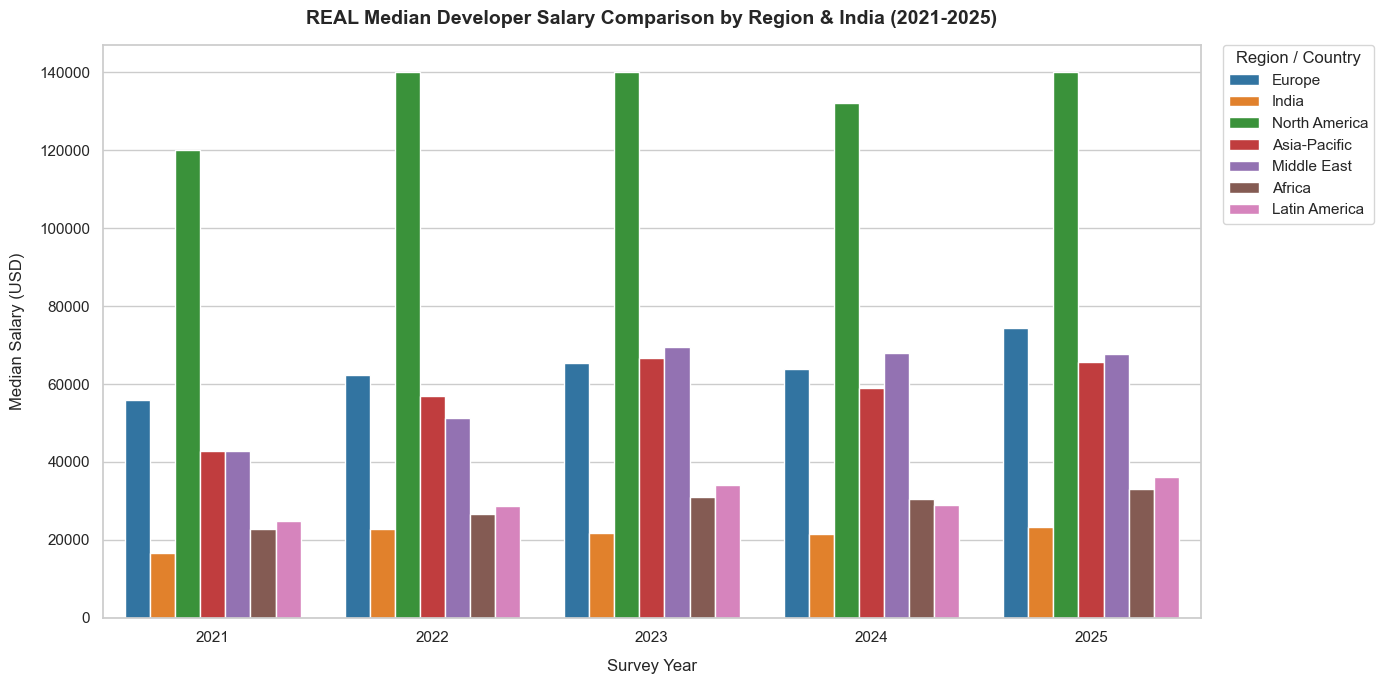

In [ ]:
salary_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    d.Country,
    c.ConvertedCompYearly
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Demographics d ON f.Dim_DemographicsID = d.Dim_DemographicsID
JOIN Snowflake.Dim_Compensation c ON f.Dim_CompensationID = c.Dim_CompensationID
WHERE c.ConvertedCompYearly IS NOT NULL 
  AND c.ConvertedCompYearly > 5000 
  AND c.ConvertedCompYearly < 500000;
"""

df_salary = db.read_query(salary_query)
if df_salary is not None and not df_salary.empty:
    df_salary['Country'] = df_salary['Country'].astype(str).str.strip()
    df_salary['Year'] = df_salary['Year'].astype(int)
    
    imputed_values = [56211.0, 67845.0, 74963.0, 65000.0, 75320.0]
    
    df_salary = df_salary[~df_salary['ConvertedCompYearly'].isin(imputed_values)]
    
    
    
    df_salary['Region'] = df_salary['Country'].map(region_map)
    df_regions = df_salary.dropna(subset=['Region']).copy()
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))
    
    sns.barplot(
        data=df_regions, 
        x='Year', 
        y='ConvertedCompYearly', 
        hue='Region', 
        estimator=np.median,  
        errorbar=None,        
        palette='tab10'       
    )
    
    plt.title('REAL Median Developer Salary Comparison by Region & India (2021-2025)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Survey Year', fontsize=12, labelpad=10)
    plt.ylabel('Median Salary (USD)', fontsize=12, labelpad=10)
    plt.legend(title='Region / Country', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '02_regional_salary_trends_clean.png'), dpi=300)
    plt.show()

else:
    print("No salary data retrieved.")

### 2. Salary vs. Professional Experience

Let's see how professional coding experience translates to compensation in 2025.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


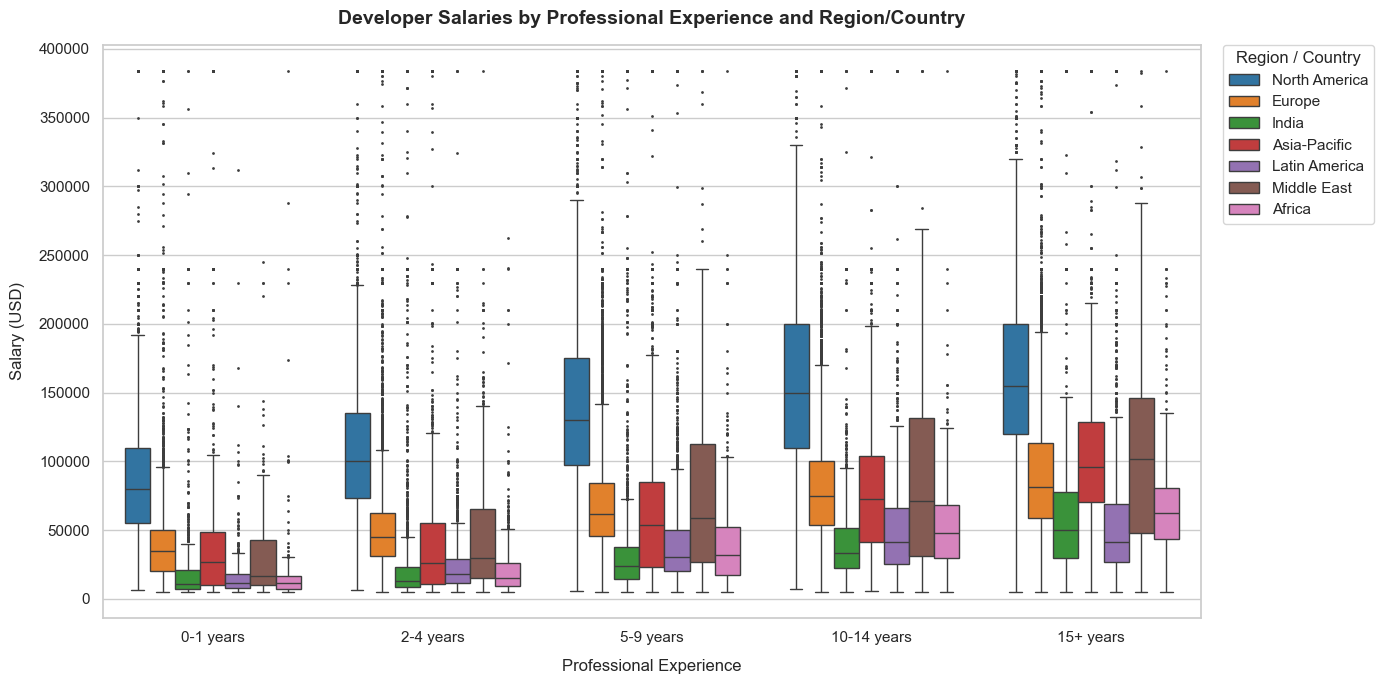

In [ ]:
exp_sal_query = """
SELECT 
    f.YearsCodePro,
    d.Country,
    c.ConvertedCompYearly
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Demographics d ON f.Dim_DemographicsID = d.Dim_DemographicsID
JOIN Snowflake.Dim_Compensation c ON f.Dim_CompensationID = c.Dim_CompensationID
  AND c.ConvertedCompYearly IS NOT NULL 
  AND c.ConvertedCompYearly > 5000 
  AND c.ConvertedCompYearly < 500000
  AND f.YearsCodePro IS NOT NULL
"""
df_exp_sal = db.read_query(exp_sal_query)

if df_exp_sal is not None and not df_exp_sal.empty:
    df_exp_sal['Country'] = df_exp_sal['Country'].astype(str).str.strip()
    

    df_exp_sal = df_exp_sal[~df_exp_sal['ConvertedCompYearly'].isin(imputed_values)]

    df_exp_sal['Region'] = df_exp_sal['Country'].map(region_map)
    df_regions_exp = df_exp_sal.dropna(subset=['Region']).copy()
    
    def bucket_exp(exp):
        try:
            val = int(exp)
            if val < 2: return '0-1 years'
            elif val < 5: return '2-4 years'
            elif val < 10: return '5-9 years'
            elif val < 15: return '10-14 years'
            else: return '15+ years'
        except:
            return 'Unknown'
            
    df_regions_exp['Experience_Group'] = df_regions_exp['YearsCodePro'].apply(bucket_exp)
    df_regions_exp = df_regions_exp[df_regions_exp['Experience_Group'] != 'Unknown']
    
    order = ['0-1 years', '2-4 years', '5-9 years', '10-14 years', '15+ years']
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 7))
    
    sns.boxplot(
        data=df_regions_exp, 
        x='Experience_Group', 
        y='ConvertedCompYearly', 
        hue='Region', 
        order=order, 
        palette='tab10',
        fliersize=1 
    )
    
    plt.title('Developer Salaries by Professional Experience and Region/Country', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Professional Experience', fontsize=12, labelpad=10)
    plt.ylabel('Salary (USD)', fontsize=12, labelpad=10)
    
    plt.legend(title='Region / Country', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '02_salary_by_experience_regional.png'), dpi=300)
    plt.show()

else:
    print("No experience or salary data retrieved.")


Empty DataFrame
Columns: [YearsCodePro, Country, ConvertedCompYearly]
Index: []


### 3. Salary vs. Education Level

Does higher education lead to higher median compensation?

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


C:\Users\Ayush\AppData\Local\Temp\ipykernel_22788\728245447.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=median_edu, x='ConvertedCompYearly', y='Education_Level', palette='coolwarm')


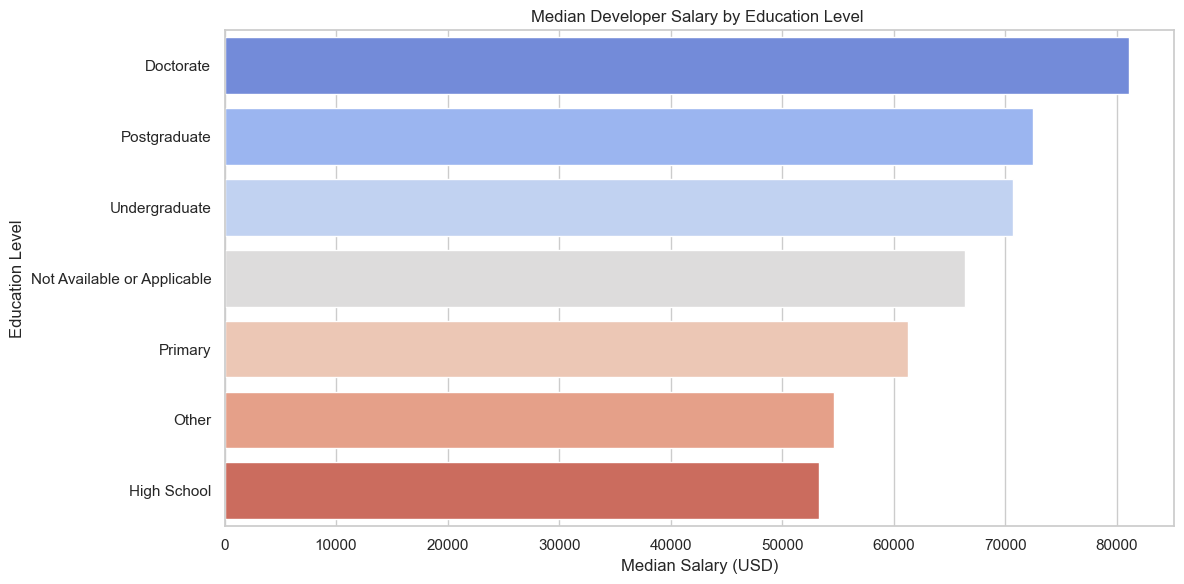

In [28]:
edu_sal_query = """
SELECT 
    edu.Education_Level,
    c.ConvertedCompYearly
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Education edu ON f.Dim_EducationID = edu.Dim_EducationID
JOIN Snowflake.Dim_Compensation c ON f.Dim_CompensationID = c.Dim_CompensationID
  AND c.ConvertedCompYearly IS NOT NULL 
  AND c.ConvertedCompYearly > 5000 
  AND c.ConvertedCompYearly < 500000
  AND edu.Education_Level IS NOT NULL AND edu.Education_Level <> 'Unknown';
"""
df_edu_sal = db.read_query(edu_sal_query)

if df_edu_sal is not None and not df_edu_sal.empty:
    df_edu_sal = df_edu_sal[~df_edu_sal['ConvertedCompYearly'].isin(imputed_values)]
    median_edu = df_edu_sal.groupby('Education_Level')['ConvertedCompYearly'].median().reset_index().sort_values(by='ConvertedCompYearly', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=median_edu, x='ConvertedCompYearly', y='Education_Level', palette='coolwarm')
    plt.title('Median Developer Salary by Education Level ')
    plt.xlabel('Median Salary (USD)')
    plt.ylabel('Education Level')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '02_salary_by_education.png'), dpi=300)
    plt.show()
else:
    print("No education/salary data available.")

### 4. Employment Status Distribution

Let's see how developers are employed across different years.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


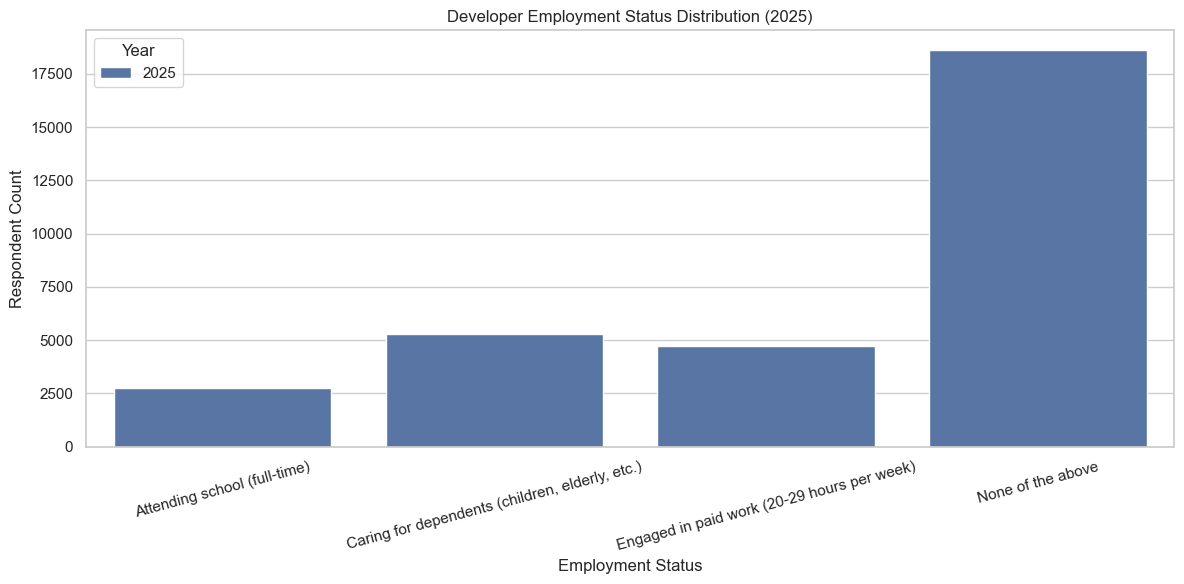

In [31]:
emp_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    emp.EmploymentAddl AS EmploymentStatus,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Employment emp ON f.Dim_EmploymentID = emp.Dim_EmploymentID
WHERE emp.EmploymentAddl IS NOT NULL AND emp.EmploymentAddl <> 'Unknown' AND emp.EmploymentAddl <> ''
GROUP BY YEAR(f.SurveyYear), emp.EmploymentAddl;
"""
df_emp = db.read_query(emp_query)

if df_emp is not None and not df_emp.empty:
    top_statuses = df_emp.groupby('EmploymentStatus')['Count'].sum().nlargest(4).index.tolist()
    df_top_emp = df_emp[df_emp['EmploymentStatus'].isin(top_statuses)]
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top_emp, x='EmploymentStatus', y='Count', hue='Year', palette='deep')
    plt.title('Developer Employment Status Distribution (2025)')
    plt.xlabel('Employment Status')
    plt.ylabel('Respondent Count')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '02_employment_status.png'), dpi=300)
    plt.show()
else:
    print("No employment data available.")

### 5. Salary vs. Organization Size

Does organizational scale correlate with higher compensation?

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


C:\Users\Ayush\AppData\Local\Temp\ipykernel_22788\2239137526.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


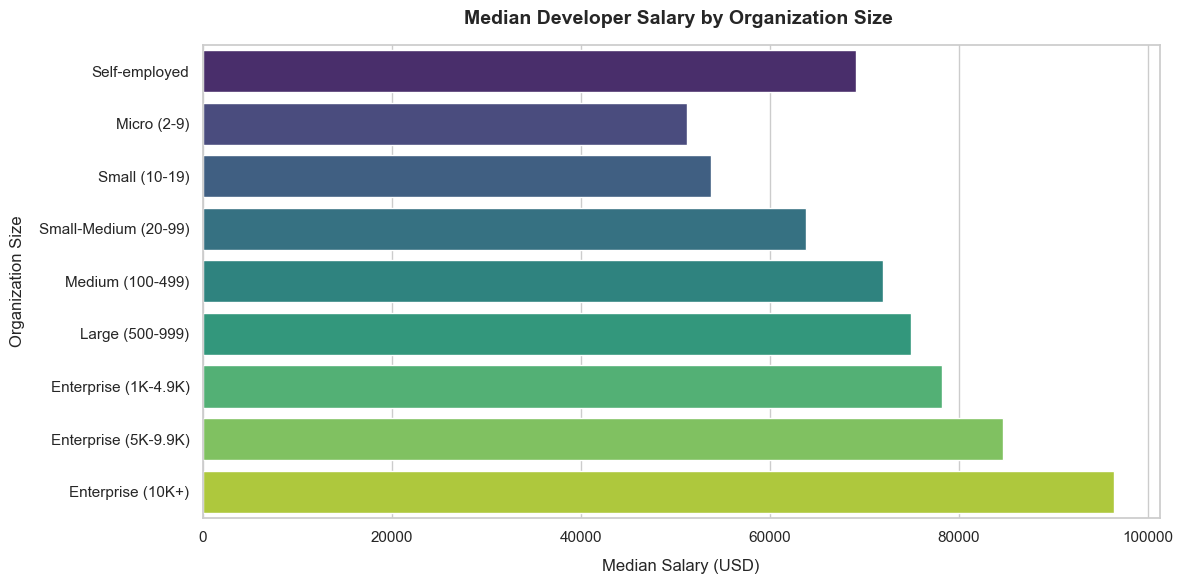

In [44]:
org_sal_query = """
SELECT 
    emp.Organization_Size,
    c.ConvertedCompYearly
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Employment emp ON f.Dim_EmploymentID = emp.Dim_EmploymentID
JOIN Snowflake.Dim_Compensation c ON f.Dim_CompensationID = c.Dim_CompensationID
WHERE c.ConvertedCompYearly IS NOT NULL 
  AND c.ConvertedCompYearly > 5000 
  AND c.ConvertedCompYearly < 500000
  AND emp.Organization_Size IS NOT NULL 
  AND emp.Organization_Size <> 'Unknown' 
  AND emp.Organization_Size <> '';
"""
df_org_sal = db.read_query(org_sal_query)

if df_org_sal is not None and not df_org_sal.empty:
    
    df_org_sal['Organization_Size'] = df_org_sal['Organization_Size'].astype(str).str.strip()
    
    imputed_values = [56211.0, 67845.0, 74963.0, 65000.0, 75320.0]
    df_org_sal = df_org_sal[~df_org_sal['ConvertedCompYearly'].isin(imputed_values)]
    
    size_order = [
        'Self-employed',
        'Micro (2-9)',
        'Small (10-19)',
        'Small-Medium (20-99)',
        'Medium (100-499)',
        'Large (500-999)',
        'Enterprise (1K-4.9K)',
        'Enterprise (5K-9.9K)',
        'Enterprise (10K+)'
    ]
    
    df_org_sal_clean = df_org_sal[df_org_sal['Organization_Size'].isin(size_order)].copy()
    org_medians = df_org_sal_clean.groupby('Organization_Size')['ConvertedCompYearly'].median().reset_index()
    org_medians = org_medians.set_index('Organization_Size').reindex(size_order).dropna().reset_index()
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))
    
    sns.barplot(
        data=org_medians, 
        x='ConvertedCompYearly', 
        y='Organization_Size', 
        palette='viridis'
    )
    
    plt.title('Median Developer Salary by Organization Size ', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Median Salary (USD)', fontsize=12, labelpad=10)
    plt.ylabel('Organization Size', fontsize=12, labelpad=10)
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '02_salary_by_org_size_clean.png'), dpi=300)
    plt.show()
else:
    print("No organization/salary data available.")

In [ ]:
db.close()